In [2]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

a = Value(1)
b = Value(2)
a + b    # it raises an error because the __add__ method is not defined

TypeError: unsupported operand type(s) for +: 'Value' and 'Value'

In [3]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data)
    
a = Value(1)
b = Value(2)
a + b    

Value(data=3)

In [4]:
class Value:
    def __init__(self, data):
        self.data = data

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data)
    
    def __mul__(self, other):
        return Value(self.data * other.data)

a = Value(1)
b = Value(2)
c = Value(5)
a * b + c # (a.__mul__(b)).__add__(c) 

Value(data=7)

In [ ]:
class Value:
    def __init__(self, data, _children=()):
        self.data = data
        self._prev = set(_children)

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other))
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other))

a = Value(1)
b = Value(2)
c = Value(5)
d = a * b + c
d

Value(data=7)

In [6]:
d._prev

{Value(data=2), Value(data=5)}

In [7]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(1)
b = Value(2)
c = Value(5)
d = a * b + c
d

Value(data=7)

In [8]:
d._op

'+'

In [26]:
from graphviz import Digraph
import math
def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ data %.4f }" % (n.data, ), shape='record')
        if n._op:
            # if the value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

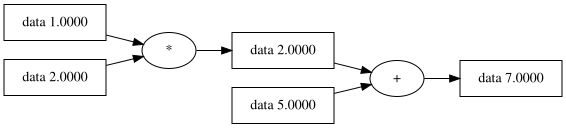

In [10]:
draw_dot(d)

In [11]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2.0, label='a')
b = Value(-3.0, label='b') 
c = Value(10.0, label='c')     
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f') 
L = d * f; L.label = 'L'

In [12]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f }" % (n.label, n.data, ), shape='record')
        if n._op:
            # if the value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

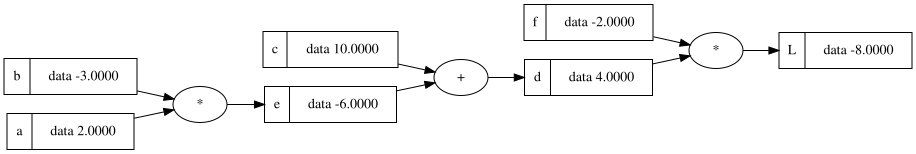

In [13]:
draw_dot(L)

### Explanation of the Above Cells

The above cells demonstrate a very simple example of a forward pass. 

In this example, we defined a function `f(x)` and visualized it. 

The forward pass is a fundamental concept in neural networks, where the input is passed through the network to produce an output.

A neural network is essentially a repetition of these forward passes, where each layer of the network performs a forward pass to transform the input and pass it to the next layer.

Now, we will dive into the backpropagation process, which is used to train the neural network by adjusting the weights based on the error of the output.

In [14]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')

a = Value(2.0, label='a')
b = Value(-3.0, label='b') 
c = Value(10.0, label='c')     
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f') 
L = d * f; L.label = 'L'

In [30]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if the value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

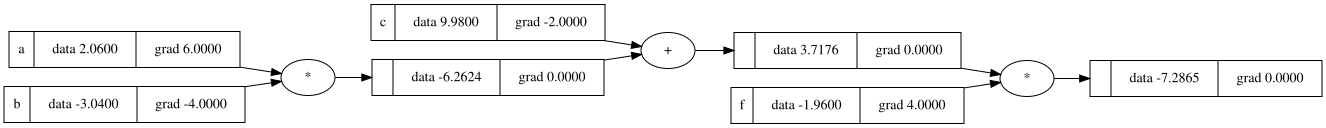

In [31]:
draw_dot(L)

In [32]:
# this is for the check the gradient of the function L = (a * b + c) * f
# when we add the h to any of the variables a, b, c, or f, the gradient of L should be equal to the derivative of L with respect to that variable

def lol(label):
    h = 1e-4
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b') 
    c = Value(10.0, label='c')     
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f') 
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b') 
    c = Value(10.0, label='c')     
    f = Value(-2.0, label='f') 
    for element in [a, b, c, f]:
        if element.label == label:
            element.data = element.data + h
    e = a * b; e.label = 'e'
    if label == 'e': e.data += h
    d = e + c; d.label = 'd'
    if label == 'd': d.data += h
    L = d * f; L.label = 'L'
    if label == 'L': L.data += h
    L2 = L.data

    print("dL/d{} = {}".format(label, ((L2 - L1) / h)))

# lol('a')
# lol('b')
# lol('c')
# lol('d')
# lol('e')   
# lol('f')   
# lol('L')   

# Chain Rule

## What is $\frac{dL}{dL}$?

Simply, it is 1.

This means the rate of change of `L` with respect to itself is 1.

## Then, what is $\frac{dL}{df}$ or $\frac{dL}{dd}$?

Here are the equations:

$$
\begin{aligned}
\frac{dL}{df} &=  \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}\\
&= \lim_{h \to 0} \frac{((f + h) \times d ) - (f \times d))}{h}\\
&= \lim_{h \to 0} \frac{(f \times d) + (h \times d) - (f \times d)}{h}\\
&= \lim_{h \to 0} \frac{(f \times d)}{h} + \lim_{h \to 0} \frac{(h \times d)}{h} - \lim_{h \to 0} \frac{((f \times d))}{h}\\
&= \lim_{h \to 0} \frac{h \times d}{h}\\
&= d\\
& \therefore \frac{dL}{df} = d
\end{aligned}
$$

Similarly, $\frac{dL}{dd}$ can be calculated in the same manner as above.

Importantly, it happens in multiplication operations. How about addition operations?

Here is example function $L = x + y$ and what is $\frac{dL}{dx}$

$$
\begin{aligned}
\frac{dL}{dx} &=  \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}\\
&= \lim_{h \to 0} \frac{(((x + h) + y ) - (x + y))}{h}\\
&= \lim_{h \to 0} \frac{(x + y) + h - (x + y)}{h}\\
&= \lim_{h \to 0} \frac{h}{h}\\
&= 1\\
& \therefore \frac{dL}{dx} = 1
\end{aligned}
$$

## Complex Case of Calculating Gradient

This is straightforward because  $ L = f \times d $, so we can determine its gradient by definition.

However, calculating $\frac{dL}{da}$ or the gradient with respect to some weight in neural networks becomes increasingly complex. 

This is where the chain rule comes into play.

Let's think about $\frac{dL}{dc}$.

When we use the chain rule, we can think like this:

$$
\frac{dL}{dc} = \frac{dL}{dd} \times \frac{dd}{dc}
$$

In this case, we already know $\frac{dL}{dd} = f$, so:

$$
\frac{dL}{dc} = f \times \frac{dd}{dc}
$$

Focus on the equation. Now we need to consider just the value in front, not the whole value.

All we need to do is store the value of each part's gradient. In this case, $d$ is made by the addition operation of $e$ and $c$.

I mean, $d = e + c$, and we saw what happens in the addition operation.

Yes, it always returns 1.

So, here is our result:

$$
\begin{aligned}
\frac{dL}{dc} &= \frac{dL}{dd} \times \frac{dd}{dc}\\
&= f \times \frac{dd}{dc}\\
&= f \times 1\\
&= f\\
\end{aligned}
$$
$$
\begin{aligned}
\frac{dL}{de} &= \frac{dL}{dd} \times \frac{dd}{de}\\
&= f \times \frac{dd}{de}\\
&= f \times 1\\
&= f\\
\end{aligned}
$$


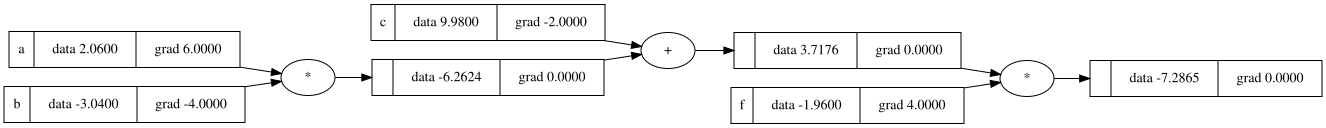

In [33]:
draw_dot(L)

In [34]:
lol('L'); lol('f'); lol('d'); lol('e'); lol('c')

dL/dL = 0.9999999999976694
dL/df = 3.9999999999995595
dL/dd = -1.9999999999953388
dL/de = -1.9999999999953388
dL/dc = -1.9999999999953388


In [35]:
# now we can easly calculate the gradient of the whole values
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
e.grad = -2.0   
c.grad = -2.0

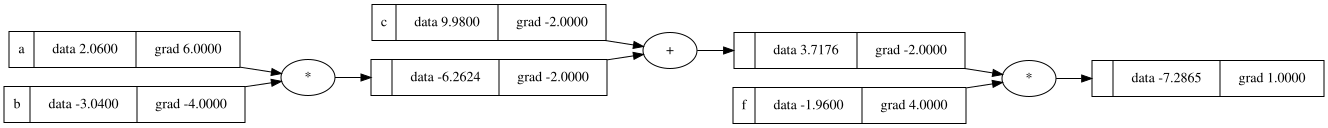

In [36]:
draw_dot(L)

## Chain rule example 

yes, calculating the gradients for `a` and `b` can be a bit tricky at first.

Let's calculate these gradients together.

$$
\begin{aligned}
\frac{dL}{da} &=  \frac{dL}{dd} \times \frac{dd}{da}\\
&=  \frac{dL}{de} \times \frac{de}{da}\\
&= (-2.0) \times \frac{de}{da} \text{ (we already calculated this before)}\\
&= (-2.0) \times b \text{ (as we saw before, the gradient of a multiplication operation is the other value of the operation)}\\
&= 6.0
\end{aligned}
$$

we can get gradient of `b` as same manner.

Let's check if it is correct using the `lol('a')` function.

In [37]:
lol('a')

dL/da = 6.000000000021544


In [38]:
a.grad = 6.0
b.grad = -4.0

# How to maximize `L`?

So, we learned that all we need to do is calculate the local gradient for the loss function and store it efficiently.

But why do we do this? Why do we need to calculate the gradient?

When we have the gradients of all parameters that construct the target value or function,

we can simply maximize the target value or function.

For example, if we have a positive gradient for `a` and a negative gradient for `b`, we can adjust `a` and `b` to maximize `L`.

Let's say the gradients are:
- `a.grad = 6.0`
- `b.grad = -4.0`

To maximize `L`, we can increase `a` and `b` in the direction of their gradients:

```python
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
```

If the gradient is positive, it means that when its value increases, it makes the target bigger.

If the gradient is negative, it means that when its value decreases, it makes the target smaller.

So, making it smaller makes the target bigger.

Let's check it

In [39]:
print("Existing L:", L.data)
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f
print("Updated L:", L.data)

Existing L: -7.286496
Updated L: -46.97032704860435


Now, we implement the rest of the backpropagation process within the inner function.

I fixed some operations by changing `=` to `+=` for `.grad` values to ensure accumulation rather than assignment.

Additionally, we added functions like `_backward` and `backward` to calculate the gradient for each part.

In the video, there are other functions to handle expressions like `1 + a`. 

These functions are useful, but I want to focus on explaining how backpropagation works.

So, I will skip these details for now. If you are interested in more details, please refer to the video.

In [43]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    
    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
      
    return out
  
  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    
    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward
    
    return out
  
  def backward(self):
    
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [44]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

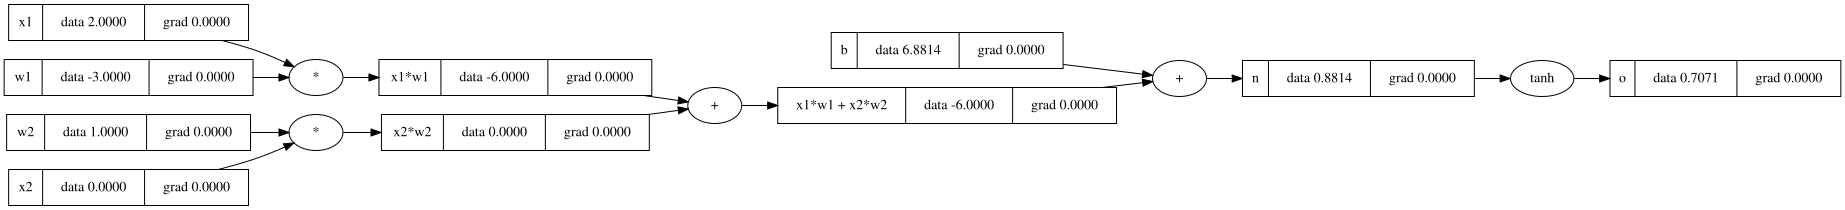

In [45]:
draw_dot(o)

In [46]:
o.backward()

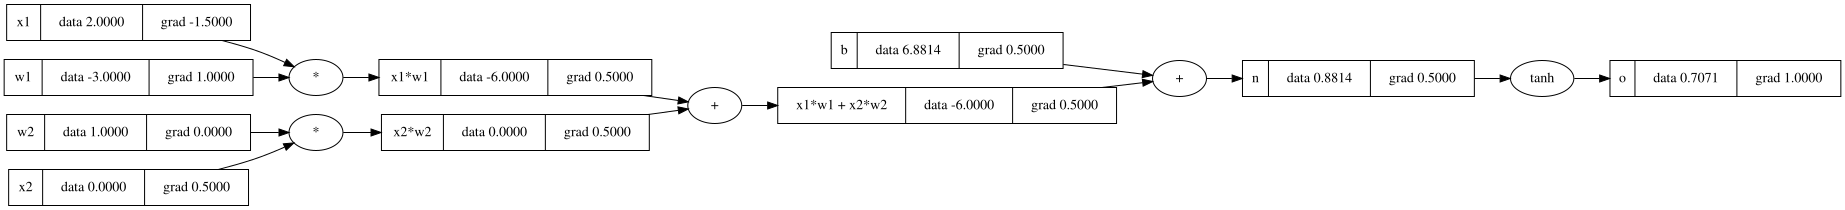

In [47]:
draw_dot(o)